# Project 06 — Switching wells ~ arsenic + distance (logistic regression)

**Tier 2 · GLMs** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P06_arsenic-logistic/P06_arsenic-logistic_12-06-2026_Opus48.ipynb)

The first **GLM**: a logistic regression for whether a household in Bangladesh **switched** away from an
arsenic-contaminated well, as a function of the well's arsenic level and the distance to the nearest safe
well. New skills: the **logit link** and **odds-ratio interpretation** (`exp(coef)`), the **prior
predictive on the probability scale**, and a **PPC for binary data** via a calibration plot.

## Learning objectives
1. Build a Bernoulli/logit GLM `logit(p) = a + b_ars·arsenic_z + b_dist·dist_z` and read coefficients as
   **odds ratios** (`exp(coef)`).
2. Do the **prior predictive on the probability scale** (push the linear predictor through `invlogit`)
   and check it covers (0, 1) without piling at 0 or 1.
3. Run a **binary PPC**: compare observed vs predicted switch rate and a **calibration plot** by
   predicted-probability decile.
4. Compare `switch~dist` vs `switch~dist+arsenic` with **PSIS-LOO** — arsenic should help a lot.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
from scipy.special import expit
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 6
rng = np.random.default_rng(RANDOM_SEED)
def zscore(x): x = np.asarray(x, float); return (x - x.mean()) / x.std()
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate binary outcomes from known a = 0.3, b_ars = 0.9, b_dist = −0.6 on two standardized predictors;
fit; confirm each truth lands inside its 90% HDI.

In [2]:
a_t, bar_t, bds_t = 0.3, 0.9, -0.6
n = 1500
ar_sim = rng.normal(0, 1, n); ds_sim = rng.normal(0, 1, n)
p_sim = expit(a_t + bar_t*ar_sim + bds_t*ds_sim)
y_sim = rng.binomial(1, p_sim)
with pm.Model() as m0:
    a = pm.Normal("a", 0, 1.5); b_ars = pm.Normal("b_ars", 0, 1); b_dist = pm.Normal("b_dist", 0, 1)
    pm.Bernoulli("y", pm.math.invlogit(a + b_ars*ar_sim + b_dist*ds_sim), observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name, tr in [("a",a_t),("b_ars",bar_t),("b_dist",bds_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_ars, b_dist]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


         mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a       0.379   0.273    0.468    1.0    3414.0
b_ars   0.932   0.822    1.043    1.0    3508.0
b_dist -0.703  -0.812   -0.599    1.0    3177.0
a recovered: True
b_ars recovered: True
b_dist recovered: True


## Data load — wells.csv (comma-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/avehtari/ROS-Examples/master/Arsenic/data/wells.csv"
CACHE = "data/wells.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw)); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE)
print("shape:", df.shape)
df.head()

loaded from raw URL
shape: (3020, 7)


,switch,arsenic,dist,dist100,assoc,educ,educ4
0,1,2.36,16.826000,0.16826,0,0,0.0
1,1,0.71,47.321999,0.47322,0,0,0.0
2,0,2.07,20.966999,0.20967,0,10,2.5
3,1,1.15,21.486000,0.21486,0,12,3.0
4,1,1.10,40.874001,0.40874,1,14,3.5


## Stage 1–2 — Question & EDA
**Question:** what makes a household **switch** away from an unsafe well — how dangerous the water is
(arsenic) and/or how far the nearest safe well is (distance)? **Target:** the odds ratios for arsenic and
distance. **Unit:** one household.
We **standardize** `arsenic` and `dist` (distance in metres) to mean 0 / sd 1 so the two coefficients
are comparable and the priors are interpretable.

n households = 3020 | overall switch rate = 0.575
arsenic: mean 1.66, range [0.51, 9.65]
dist (m): mean 48.3, range [0.4, 339.5]


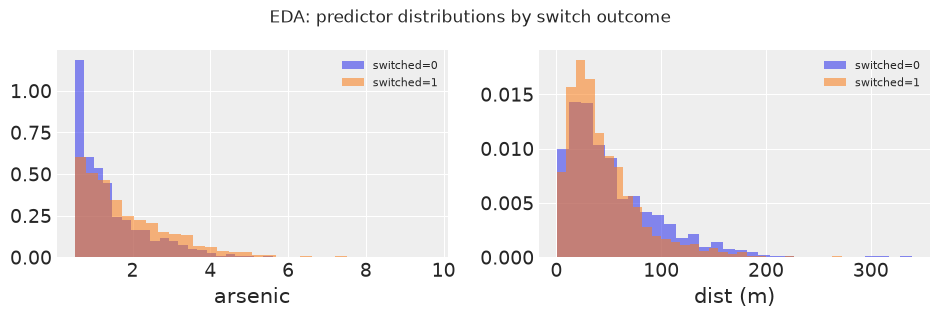

In [4]:
switch = df["switch"].values.astype(int)
arsenic_z = zscore(df["arsenic"].values)
dist_z = zscore(df["dist"].values)
print(f"n households = {len(switch)} | overall switch rate = {switch.mean():.3f}")
print(f"arsenic: mean {df['arsenic'].mean():.2f}, range [{df['arsenic'].min():.2f}, {df['arsenic'].max():.2f}]")
print(f"dist (m): mean {df['dist'].mean():.1f}, range [{df['dist'].min():.1f}, {df['dist'].max():.1f}]")
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
for a_, col, lab in [(ax[0], df['arsenic'].values, 'arsenic'), (ax[1], df['dist'].values, 'dist (m)')]:
    for s_, c in [(0,'switched=0'),(1,'switched=1')]:
        a_.hist(col[switch==s_], bins=30, alpha=.55, label=c, density=True)
    a_.set_xlabel(lab); a_.legend(fontsize=8)
plt.suptitle("EDA: predictor distributions by switch outcome"); plt.tight_layout(); plt.show()

## Stage 3 — Model specification
$$\mathrm{switch}_i \sim \mathrm{Bernoulli}(p_i), \quad \mathrm{logit}(p_i) = a + b_{ars}\,\mathrm{arsenic\_z}_i + b_{dist}\,\mathrm{dist\_z}_i,$$
$$a \sim \mathrm{Normal}(0, 1.5), \quad b_{ars}, b_{dist} \sim \mathrm{Normal}(0, 1).$$
On standardized predictors, `Normal(0,1)` on a logit coefficient is weakly-informative: it keeps the
odds ratio `exp(b)` within a plausible band (roughly 1/7 to 7 per sd) rather than allowing absurd
near-certain switching.

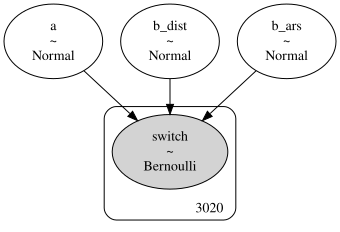

In [5]:
def make_model(use_ars=True, use_dist=True):
    with pm.Model() as mdl:
        a = pm.Normal("a", 0, 1.5)
        eta = a
        if use_dist:
            b_dist = pm.Normal("b_dist", 0, 1); eta = eta + b_dist*dist_z
        if use_ars:
            b_ars = pm.Normal("b_ars", 0, 1); eta = eta + b_ars*arsenic_z
        pm.Bernoulli("switch", pm.math.invlogit(eta), observed=switch)
    return mdl
model = make_model(True, True)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| a,b_ars,b_dist -> switch")

## Stage 4 — Prior predictive on the PROBABILITY scale [the GLM lesson]
Push prior draws of the linear predictor through `invlogit` and check the implied switching
**probabilities** spread across (0, 1) without piling up at 0 or 1 — the signature of a sane logit prior.

Sampling: [a, b_ars, b_dist, switch]


prior predictive p: mean 0.48, frac<0.05 = 0.07, frac>0.95 = 0.07


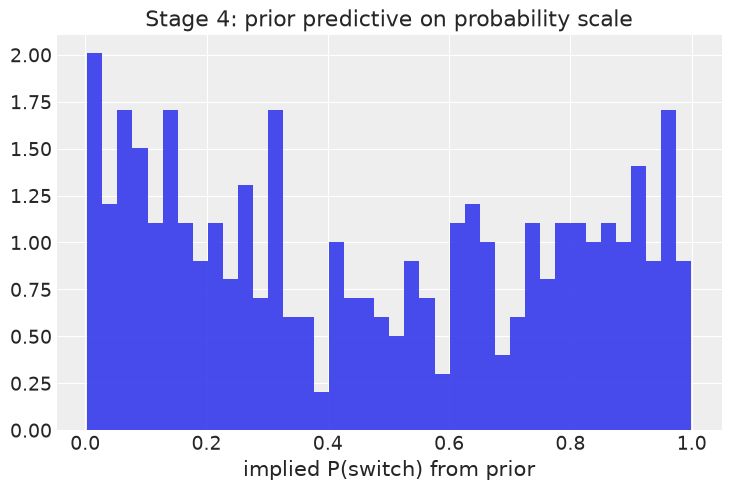

Good: mass spread across (0,1), not piled at the extremes.


In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=400, random_seed=RANDOM_SEED)
ap = pp.prior["a"].values.reshape(-1); bar = pp.prior["b_ars"].values.reshape(-1); bds = pp.prior["b_dist"].values.reshape(-1)
xr = rng.normal(0, 1, ap.size); xd = rng.normal(0, 1, ap.size)
p_prior = expit(ap + bar*xr + bds*xd)
print(f"prior predictive p: mean {p_prior.mean():.2f}, "
      f"frac<0.05 = {(p_prior<0.05).mean():.2f}, frac>0.95 = {(p_prior>0.95).mean():.2f}")
plt.hist(p_prior, bins=40, density=True, alpha=.85)
plt.xlabel("implied P(switch) from prior"); plt.title("Stage 4: prior predictive on probability scale")
plt.show()
print("Good: mass spread across (0,1), not piled at the extremes.")

## Stage 5 — Fit (full model)

In [7]:
t0 = time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_dist, b_ars]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


Sampling: [switch]


wall-clock 16.9s


## Stage 6 — Diagnostics

         mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a       0.333  0.038   0.263    0.407    1.0    3057.0    2892.0
b_ars   0.510  0.046   0.427    0.600    1.0    3111.0    2994.0
b_dist -0.346  0.041  -0.421   -0.265    1.0    3421.0    2958.0

divergences: 0 | BFMI: [1.077 1.077 1.169 0.983]


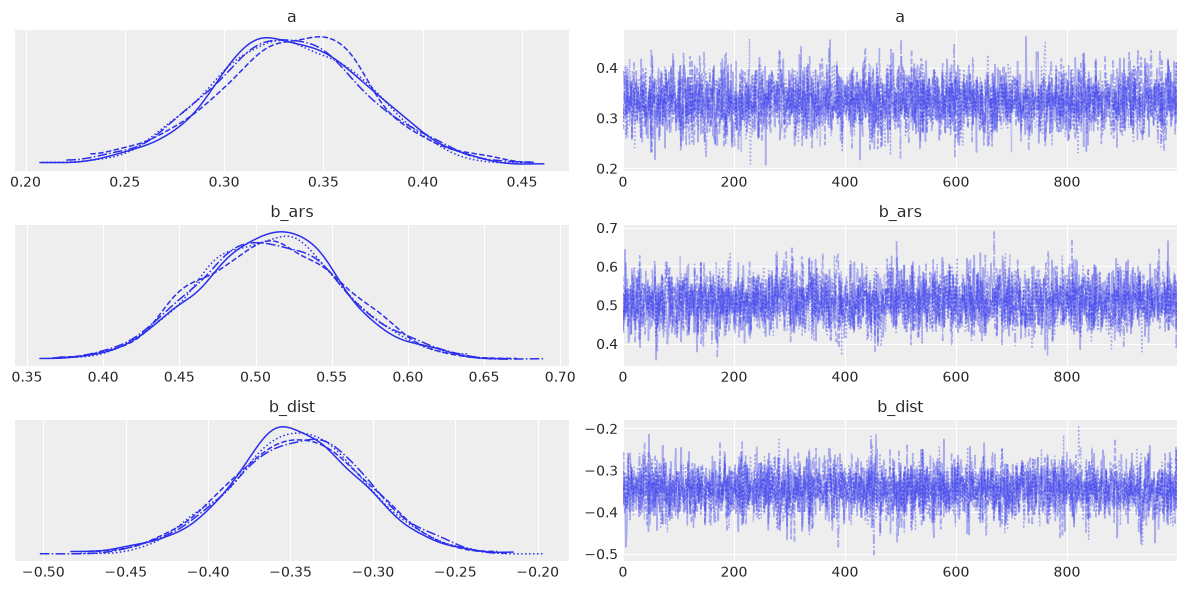

In [8]:
summ = az.summary(idata, var_names=["a","b_ars","b_dist"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a","b_ars","b_dist"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation: odds ratios

arsenic : coef +0.510 (94% HDI +0.427,+0.600) -> OR 1.67 per +1 sd (94% HDI 1.53,1.82)
distance: coef -0.346 (94% HDI -0.421,-0.265) -> OR 0.71 per +1 sd (94% HDI 0.66,0.77)

Reading: higher arsenic raises the odds of switching; greater distance lowers them.


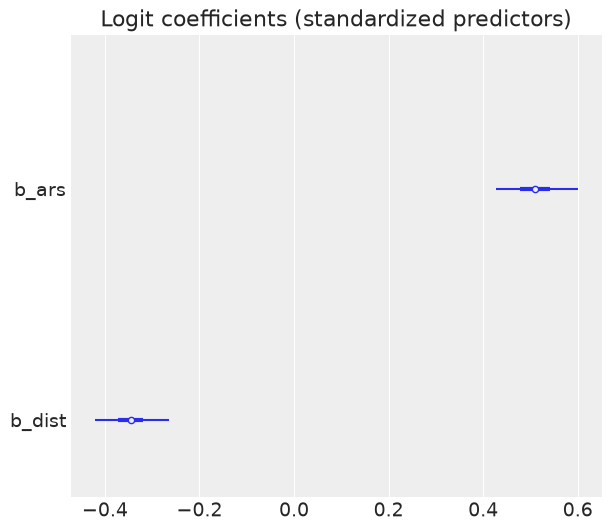

In [9]:
post = idata.posterior
for name, lab in [("b_ars","arsenic"),("b_dist","distance")]:
    b = post[name].values.reshape(-1); orr = np.exp(b)
    hdi = az.hdi(idata, var_names=[name], hdi_prob=0.94)[name].values
    or_hdi = np.exp(hdi)
    print(f"{lab:8s}: coef {b.mean():+.3f} (94% HDI {hdi[0]:+.3f},{hdi[1]:+.3f}) "
          f"-> OR {orr.mean():.2f} per +1 sd (94% HDI {or_hdi[0]:.2f},{or_hdi[1]:.2f})")
print("\nReading: higher arsenic raises the odds of switching; greater distance lowers them.")
az.plot_forest(idata, var_names=["b_ars","b_dist"], combined=True, hdi_prob=0.94)
plt.title("Logit coefficients (standardized predictors)"); plt.show()

## Stage 8 — PPC for binary data: switch rate + calibration plot
Discrepancy stat = the **overall proportion switched**; then a calibration plot grouping households into
predicted-probability **deciles** and comparing observed vs predicted switch rate in each bin.

observed switch rate = 0.575 | posterior-predictive rate mean 0.575, bayes-p = 0.51


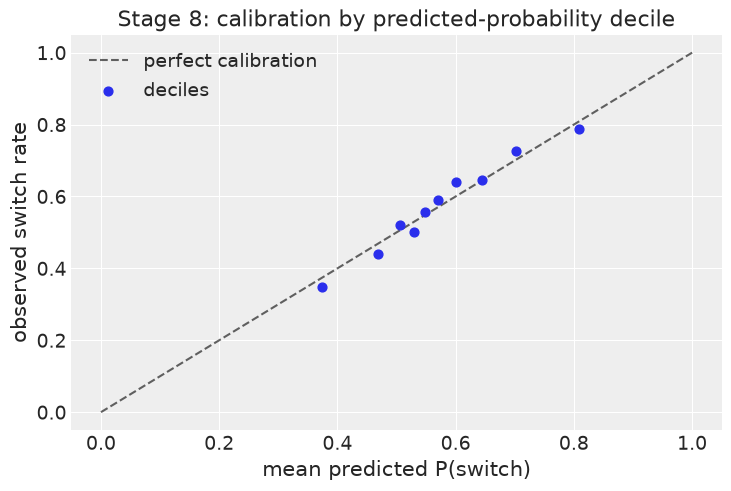

calibration max |obs-pred| across deciles: 0.039


In [10]:
ppc = idata.posterior_predictive["switch"].values.reshape(-1, switch.size)
pred_rate = ppc.mean(axis=1)
obs_rate = switch.mean()
p_val = float((pred_rate >= obs_rate).mean())
print(f"observed switch rate = {obs_rate:.3f} | posterior-predictive rate "
      f"mean {pred_rate.mean():.3f}, bayes-p = {p_val:.2f}")
# calibration by decile of posterior-mean p
p_hat = expit(az.extract(idata)["a"].values.mean()
              + az.extract(idata)["b_ars"].values.mean()*arsenic_z
              + az.extract(idata)["b_dist"].values.mean()*dist_z)
bins = pd.qcut(p_hat, 10, labels=False, duplicates="drop")
obs_b, pred_b = [], []
for b in np.unique(bins):
    m = bins == b; obs_b.append(switch[m].mean()); pred_b.append(p_hat[m].mean())
plt.plot([0,1],[0,1],"k--",alpha=.6,label="perfect calibration")
plt.scatter(pred_b, obs_b, s=40, zorder=3, label="deciles")
plt.xlabel("mean predicted P(switch)"); plt.ylabel("observed switch rate")
plt.title("Stage 8: calibration by predicted-probability decile"); plt.legend(); plt.show()
print("calibration max |obs-pred| across deciles:", f"{np.max(np.abs(np.array(obs_b)-np.array(pred_b))):.3f}")

## Stage 9 — Comparison: `switch~dist` vs `switch~dist+arsenic` (PSIS-LOO)
Does knowing the well's arsenic level help predict switching beyond distance alone? Expect a large gain.

In [11]:
model_dist = make_model(use_ars=False, use_dist=True)
with model_dist:
    idata_dist = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                           progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"dist": idata_dist, "dist+arsenic": idata})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size * idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
maxk = max(az.loo(x, pointwise=True).pareto_k.values.max() for x in [idata, idata_dist])
print(f"\nmax Pareto k-hat: {maxk:.2f} | threshold {thr:.2f}")
row2 = cmp.iloc[1]
print(f"elpd_diff of 2nd-ranked = {row2['elpd_diff']:.2f} +/- {row2['dse']:.2f} SE -> arsenic helps a lot")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_dist]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


              rank     elpd_loo  elpd_diff        dse    weight
dist+arsenic     0 -1968.491900   0.000000   0.000000  0.939611
dist             1 -2040.217883  71.725984  12.130578  0.060389



max Pareto k-hat: 0.16 | threshold 0.70
elpd_diff of 2nd-ranked = 71.73 +/- 12.13 SE -> arsenic helps a lot


## Stage 10 — Power-scaling prior sensitivity (b_ars, b_dist)

In [12]:
post = az.extract(idata); ad = post["a"].values; bar = post["b_ars"].values; bds = post["b_dist"].values
logprior = st.norm.logpdf(ad,0,1.5) + st.norm.logpdf(bar,0,1) + st.norm.logpdf(bds,0,1)
print("alpha   E[b_ars]   E[b_dist]")
for al in [0.8, 1.0, 1.25]:
    wgt = np.exp((al-1)*logprior); wgt /= wgt.sum()
    print(f" {al:4.2f}    {np.sum(wgt*bar):+.3f}     {np.sum(wgt*bds):+.3f}")

alpha   E[b_ars]   E[b_dist]
 0.80    +0.510     -0.346
 1.00    +0.510     -0.346
 1.25    +0.509     -0.346


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** the ROS analysis adds an **arsenic × distance interaction** and an
**education** term, and considers a **non-linear** (e.g. log-arsenic or spline) effect — the diminishing
return of distance. The interaction is the natural immediate expansion.

**Decision (Stage 12) — headline:** *households are driven to switch wells mainly by **how contaminated
their water is** — each +1 sd of arsenic multiplies the odds of switching by ≈ 1.8 — and are modestly
deterred by **distance** to a safe well; arsenic dominates, and a model without it predicts switching far
worse.*

In [13]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P06_idata.nc"); print("saved report/P06_idata.nc")

saved report/P06_idata.nc


## Exercises
1. Add the **arsenic × distance** interaction. Does the arsenic effect depend on how far the safe well is?
2. Add **education** (`educ4`) and interpret its odds ratio. Does it change the arsenic coefficient?
3. Replace `arsenic_z` with `log(arsenic)` (standardized). Compare the calibration plots — which fits the
   low-arsenic households better?